# ASSIGNMENT GROUP 12 NOTEBOOK


# Essential importing

In [270]:
from __future__ import annotations

from pathlib import Path

import io
import zipfile
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import requests  # used only if we download Fama-French data
except Exception:
    requests = None

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')


In [271]:
if importlib.util.find_spec('statsmodels') is None:
    raise ModuleNotFoundError(
        "Lecture 4 requires statsmodels. In Jupyter, run: %pip install statsmodels"
    )

import statsmodels.api as sm


## Data Loading and Basic Checks

**Screen:** Through CapitalIQ, we screened for 3 factors:
- **P/BV** _[LTM as of 12/31/204]_
- **% Price change** _[12/31/2013-12/31/2014]_
- **Return on Equity** _[FY 2014]_

732 Stocks were then each given a score (Lower = Better) based on their relative position for each of the 3 factors. This score was then aggregated to find the 7 stocks with the lowest total score.

**Data:** Monthly dividend-adjusted share prices for TTWO, GHC, HQH, GBX, RDN, BBAR, SANM and **SPY** (S&P 500 proxy) (`Charting Excel Export - Test.xls`)

The export contains dividend-adjusted price levels $P_t$, so monthly simple returns are computed via:

$$r_t = \frac{P_t}{P_{t-1}} - 1$$

After computing returns, SPY is separated from the seven stock series. All series are resampled to beginning-of-month frequency before merging.

In [272]:
import re

DATA_PATH = '/content/sample_data/Charting Excel Export - Test.xls'

START_DATE = pd.Timestamp('01/01/1998')
END_DATE   = pd.Timestamp('31/12/2024')


def _load_charting_xls(path: str) -> pd.DataFrame:
    """
    Read an Excel Export file (Pane 1 sheet) from Capital IQ.
    Returns a beginning-of-month DatetimeIndex DataFrame.

    Capital IQ labels end-of-month prices on the 1st of the following month
    when the month ends on a weekend or holiday. Shift those dates back one day
    so they are grouped with the correct prior month before resampling.
    """
    raw = pd.read_excel(path, sheet_name='Pane 1', header=None)
    mask = raw.notna().any(axis=1)
    data = raw[mask].copy()
    data.columns = data.iloc[0]          # first surviving row is the header
    data = data.iloc[1:].copy()
    data = data.rename(columns={data.columns[0]: 'date'})
    data['date'] = pd.to_datetime(data['date'])
    data = data.set_index('date').apply(pd.to_numeric, errors='coerce')
    # Dates on the 1st of a month are end-of-prior-month prices reported on the
    # next business day. Shift them back one day into the correct month.
    data.index = data.index - pd.to_timedelta((data.index.day == 1).astype(int), unit='D')
    # Group by calendar month (last observation), then label beginning-of-month
    # to match the Fama-French date convention.
    data = data.resample('ME').last()
    data.index = data.index.to_period('M').to_timestamp()
    return data


def _extract_ticker(col: str) -> str:
    """Pull the ticker symbol out of a long Charting column label."""
    m = re.search(r'\((?:[A-Za-z]+:)?([A-Z]+)\)', col)
    return m.group(1) if m else col


# ── Load all assets from a single file ────────────────────────────────────────
all_prices = _load_charting_xls(DATA_PATH)
all_prices.columns = [_extract_ticker(c) for c in all_prices.columns]

# Dividend-adjusted price levels → monthly simple return
# r_t = P_t / P_{t-1} - 1
all_ret = all_prices.pct_change().dropna(how='all')

# ── Split stocks and S&P 500 proxy (SPY) ──────────────────────────────────────
stock_tickers = [c for c in all_ret.columns if c != 'SPY']
stocks_prices = all_prices[stock_tickers]   # kept for stock-selection cell below
stocks_ret    = all_ret[stock_tickers]
spy_ret       = all_ret[['SPY']]

# ── Merge stocks + SPY ────────────────────────────────────────────────────────
df_ret = stocks_ret.join(spy_ret, how='inner').dropna(how='all')
df_ret.index.name = 'date'

df_ret = df_ret.loc[START_DATE:END_DATE]

print(f'Data file    : {DATA_PATH}')
print(f'Rows (months): {df_ret.shape[0]}, Columns (assets): {df_ret.shape[1]}')
print(f'Date range   : {df_ret.index.min().date()} to {df_ret.index.max().date()}')
df_ret.head()

Data file    : /content/sample_data/Charting Excel Export - Test.xls
Rows (months): 324, Columns (assets): 8
Date range   : 1998-01-01 to 2024-12-01


,GHC,TTWO,HQH,GBX,RDN,BBAR,SANM,SPY
date,,,,,,,,
1998-01-01,0.008887,0.136360,0.040983,-0.058117,0.074816,0.008065,0.132911,0.041986
1998-02-01,0.012004,0.140001,0.074803,-0.007722,0.078950,0.154286,0.175047,0.069715
1998-03-01,0.097086,0.122804,0.007327,0.073930,-0.029091,-0.009901,-0.113311,0.054745
1998-04-01,-0.009306,0.046875,-0.010909,0.061497,-0.032772,-0.030000,0.286863,0.012791
1998-05-01,0.031153,-0.074624,-0.014706,-0.013699,-0.062488,-0.210310,-0.134723,-0.020769


In [273]:
df_ret.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 324 entries, 1998-01-01 to 2024-12-01
Freq: MS
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GHC     324 non-null    float64
 1   TTWO    324 non-null    float64
 2   HQH     324 non-null    float64
 3   GBX     324 non-null    float64
 4   RDN     324 non-null    float64
 5   BBAR    324 non-null    float64
 6   SANM    324 non-null    float64
 7   SPY     324 non-null    float64
dtypes: float64(8)
memory usage: 22.8 KB


In [274]:
# Full descriptive statistics for all available assets.
df_ret.describe().T

,count,mean,std,min,25%,50%,75%,max
GHC,324.000000,0.006925,0.069012,-0.337562,-0.032341,0.001907,0.044435,0.289023
TTWO,324.000000,0.022480,0.148434,-0.574097,-0.056347,0.018615,0.090750,0.954739
HQH,324.000000,0.010642,0.076685,-0.262069,-0.027030,0.010517,0.051711,0.491586
GBX,324.000000,0.017330,0.160132,-0.615768,-0.066384,0.006075,0.088791,1.170918
RDN,324.000000,0.018050,0.193848,-0.746946,-0.049823,0.008379,0.080654,1.754571
BBAR,324.000000,0.038568,0.168547,-0.547406,-0.062920,0.019062,0.127668,0.494981
SANM,324.000000,0.016334,0.177594,-0.585366,-0.082022,0.010118,0.110002,1.386418
SPY,324.000000,0.008295,0.046539,-0.224162,-0.016414,0.013142,0.036947,0.146239


## Risk-Free Rate ($r_f$) and Market Excess Return via Fama-French

The Ken French file reports values in percent, so we divide by 100 to convert them to decimal returns.

In [275]:
USE_FAMA_FRENCH_RF = True

# Ken French data library (Dartmouth) — loading the data directly from the URL.
FF_ZIP_URL = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip'
LOCAL_FF_ZIP = Path('../../Lecture_2/Code/Source/F-F_Research_Data_5_Factors_2x3_CSV.zip')


In [276]:
def read_ff_zip(zip_bytes: bytes) -> pd.DataFrame:
    z = zipfile.ZipFile(io.BytesIO(zip_bytes))
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as file:
        df_factors = pd.read_csv(file, skiprows=3, index_col=0)

    # Keep monthly data only (cut before the annual section begins).
    df_factors = df_factors.loc[:'202412']
    df_factors.index = pd.to_datetime(df_factors.index, format='%Y%m')
    df_factors = df_factors.apply(pd.to_numeric) / 100.0  # convert % to decimal
    df_factors = df_factors.rename_axis('date').reset_index()
    return df_factors


if USE_FAMA_FRENCH_RF:
    try:
        if requests is None:
            raise ModuleNotFoundError('requests is not available')

        # Download the ZIP file
        response = requests.get(FF_ZIP_URL, timeout=30)
        response.raise_for_status()
        df_factors = read_ff_zip(response.content)

        # Merge with returns (inner join: keeps only common dates).
        df = df_ret.reset_index().merge(df_factors, how='inner', on='date').set_index('date').sort_index()
        print('Using Ken French website download.')

    except Exception as e:
        if LOCAL_FF_ZIP.exists():
            print(f'Download failed ({type(e).__name__}). Using local fallback ZIP instead.')
            df_factors = read_ff_zip(LOCAL_FF_ZIP.read_bytes())
            df = df_ret.reset_index().merge(df_factors, how='inner', on='date').set_index('date').sort_index()
        else:
            print(f'Download failed ({type(e).__name__}). Proceeding with r_f = 0.')
            USE_FAMA_FRENCH_RF = False

else:
    # Offline/error fallback: proceed with r_f = 0 and no factor columns.
    df = df_ret.copy()

print(f'Merged dataset rows: {df.shape[0]}, date range: {df.index.min().date()} to {df.index.max().date()}')
df.head()


Using Ken French website download.
Merged dataset rows: 324, date range: 1998-01-01 to 2024-12-01


,GHC,TTWO,HQH,GBX,RDN,BBAR,SANM,SPY,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,,,,,,,,,
1998-01-01,0.008887,0.136360,0.040983,-0.058117,0.074816,0.008065,0.132911,0.041986,0.001400,-0.012800,-0.016800,0.009100,-0.006200,0.004300
1998-02-01,0.012004,0.140001,0.074803,-0.007722,0.078950,0.154286,0.175047,0.069715,0.070400,0.000500,-0.009300,-0.003700,-0.025800,0.003900
1998-03-01,0.097086,0.122804,0.007327,0.073930,-0.029091,-0.009901,-0.113311,0.054745,0.047600,-0.007300,0.013800,-0.005500,-0.002300,0.003900
1998-04-01,-0.009306,0.046875,-0.010909,0.061497,-0.032772,-0.030000,0.286863,0.012791,0.007400,0.000100,0.010300,-0.016800,-0.003600,0.004300
1998-05-01,0.031153,-0.074624,-0.014706,-0.013699,-0.062488,-0.210310,-0.134723,-0.020769,-0.030500,-0.030000,0.034100,0.010300,0.024700,0.004000


In [277]:
def run_capm_table(returns: pd.DataFrame, market_excess: pd.Series, rf: pd.Series) -> pd.DataFrame:
    rows = []
    for ticker in returns.columns:
        X = sm.add_constant(market_excess)
        y = returns[ticker] - rf
        model = sm.OLS(y, X).fit()

        rows.append({
            'Ticker': ticker,
            'Mean excess return (monthly)': y.mean(),
            'CAPM required excess return (monthly)': model.params['Mkt-RF'] * market_excess.mean(),
            'Alpha (monthly)': model.params['const'],
            'Alpha (annualised)': (1 + model.params['const']) ** 12 - 1,
            'Beta': model.params['Mkt-RF'],
            'Alpha t-stat': model.tvalues['const'],
            'R-squared': model.rsquared,
        })

    return pd.DataFrame(rows).sort_values(['Alpha (monthly)', 'Alpha t-stat'], ascending=False).set_index('Ticker')

In [278]:
available_tickers = df_ret.columns.tolist()
market_excess = df['Mkt-RF'] if USE_FAMA_FRENCH_RF and 'Mkt-RF' in df.columns else pd.Series(0.0, index=df.index, name='Mkt-RF')
rf = df['RF'] if USE_FAMA_FRENCH_RF and 'RF' in df.columns else pd.Series(0.0, index=df.index, name='RF')

alpha_table = run_capm_table(df_ret[available_tickers], market_excess, rf)
my_stock_selection = alpha_table.head(7).index.tolist()

print('Top 7 high-alpha assets from the full sample:')
print(my_stock_selection)
alpha_table.head(10)

Top 7 high-alpha assets from the full sample:
['BBAR', 'TTWO', 'RDN', 'GBX', 'HQH', 'SPY', 'GHC']


,Mean excess return (monthly),CAPM required excess return (monthly),Alpha (monthly),Alpha (annualised),Beta,Alpha t-stat,R-squared
Ticker,,,,,,,
BBAR,0.036918,0.009224,0.027693,0.387912,1.375055,3.157576,0.143438
TTWO,0.020829,0.007650,0.013179,0.170134,1.140384,1.690357,0.127202
RDN,0.016399,0.010525,0.005874,0.072810,1.568986,0.581137,0.141004
GBX,0.015679,0.010587,0.005092,0.062840,1.578231,0.635391,0.209017
HQH,0.008992,0.006445,0.002547,0.030991,0.960747,0.725900,0.338149
SPY,0.006644,0.006246,0.000399,0.004795,0.931035,0.406426,0.859886
GHC,0.005275,0.004941,0.000334,0.004018,0.736490,0.099044,0.244984
SANM,0.014683,0.014507,0.000176,0.002116,2.162526,0.021374,0.319315


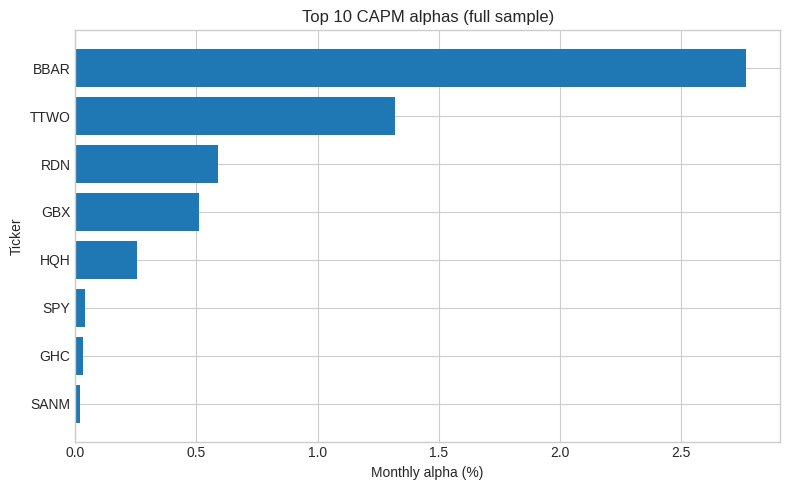

In [279]:
plot_table = alpha_table.head(10).copy().iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_table.index, 100 * plot_table['Alpha (monthly)'], color='tab:blue')
ax.set_title('Top 10 CAPM alphas (full sample)')
ax.set_xlabel('Monthly alpha (%)')
ax.set_ylabel('Ticker')
plt.tight_layout()
plt.show()

## Stock Selection


In [280]:
market_excess = df['Mkt-RF'] if USE_FAMA_FRENCH_RF and 'Mkt-RF' in df.columns else pd.Series(0.0, index=df.index, name='Mkt-RF')
rf = df['RF'] if USE_FAMA_FRENCH_RF and 'RF' in df.columns else pd.Series(0.0, index=df.index, name='RF')

my_stock_selection = stocks_prices.columns.tolist()

print('Selected stocks:')
print(my_stock_selection)


Selected stocks:
['GHC', 'TTWO', 'HQH', 'GBX', 'RDN', 'BBAR', 'SANM']


In [281]:
missing = sorted(set(my_stock_selection) - set(df.columns))
if missing:
    raise ValueError(f'Tickers not found in data: {missing}')

stocks = df[my_stock_selection].copy()
stocks.describe().T


,count,mean,std,min,25%,50%,75%,max
GHC,324.000000,0.006925,0.069012,-0.337562,-0.032341,0.001907,0.044435,0.289023
TTWO,324.000000,0.022480,0.148434,-0.574097,-0.056347,0.018615,0.090750,0.954739
HQH,324.000000,0.010642,0.076685,-0.262069,-0.027030,0.010517,0.051711,0.491586
GBX,324.000000,0.017330,0.160132,-0.615768,-0.066384,0.006075,0.088791,1.170918
RDN,324.000000,0.018050,0.193848,-0.746946,-0.049823,0.008379,0.080654,1.754571
BBAR,324.000000,0.038568,0.168547,-0.547406,-0.062920,0.019062,0.127668,0.494981
SANM,324.000000,0.016334,0.177594,-0.585366,-0.082022,0.010118,0.110002,1.386418


## Correlations (Diversification Intuition)

Correlation is not the optimisation input (that is $\Sigma$), but it is still a quick way to see whether diversification is likely to help.

In [282]:
corr = stocks.corr()
corr

,GHC,TTWO,HQH,GBX,RDN,BBAR,SANM
GHC,1.000000,0.226748,0.255545,0.414201,0.285949,0.244318,0.279461
TTWO,0.226748,1.000000,0.285062,0.150649,0.120668,0.164341,0.271413
HQH,0.255545,0.285062,1.000000,0.226307,0.144228,0.230041,0.391466
GBX,0.414201,0.150649,0.226307,1.000000,0.261260,0.236542,0.398326
RDN,0.285949,0.120668,0.144228,0.261260,1.000000,0.199700,0.381126
BBAR,0.244318,0.164341,0.230041,0.236542,0.199700,1.000000,0.255465
SANM,0.279461,0.271413,0.391466,0.398326,0.381126,0.255465,1.000000


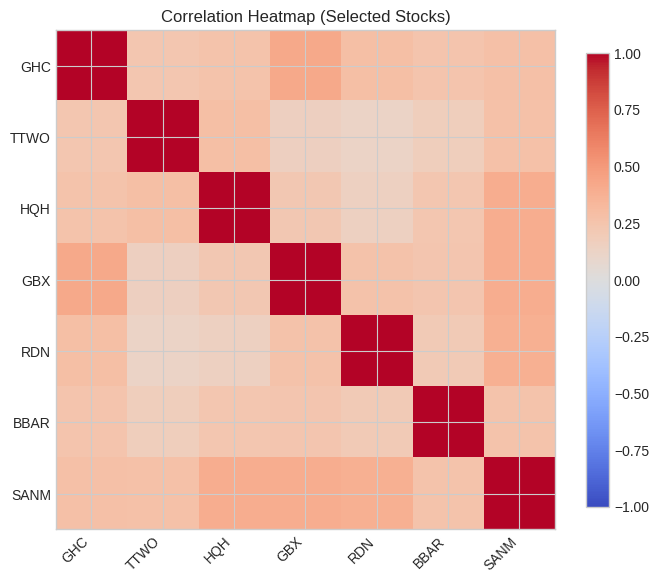

In [283]:
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(my_stock_selection)))
ax.set_yticks(range(len(my_stock_selection)))
ax.set_xticklabels(my_stock_selection, rotation=45, ha='right')
ax.set_yticklabels(my_stock_selection)
ax.set_title('Correlation Heatmap (Selected Stocks)')
fig.colorbar(image, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()


## Portfolio Inputs: $\mu$ and $\Sigma$

For portfolio weights $w$ and return vector $r$:
- Expected excess return: $\mathbb{E}[r_p^e] = w^\top \mu^e$
- Variance: $\mathrm{Var}(r_p) = w^\top \Sigma w$

We estimate $\Sigma$ from historical data.

In [284]:
# Population-style covariance estimate from the lecture notes: Sigma_hat = (1/T) R^T R
R = stocks.subtract(stocks.mean())
T = len(stocks)
Sigma_pop = (R.T @ R) / T

# Unbiased sample estimate divides by (T-1) instead.
Sigma_samp = (R.T @ R) / (T - 1)

Sigma = Sigma_samp
Sigma.head()

,GHC,TTWO,HQH,GBX,RDN,BBAR,SANM
GHC,0.004763,0.002323,0.001352,0.004577,0.003825,0.002842,0.003425
TTWO,0.002323,0.022033,0.003245,0.003581,0.003472,0.004112,0.007155
HQH,0.001352,0.003245,0.005881,0.002779,0.002144,0.002973,0.005331
GBX,0.004577,0.003581,0.002779,0.025642,0.008110,0.006384,0.011328
RDN,0.003825,0.003472,0.002144,0.008110,0.037577,0.006525,0.013121


## Excess Returns

The tangency portfolio uses the vector of expected excess returns:

$$\mu^e = \mathbb{E}[r_t - r_{f,t}].$$

In [285]:
stocks_excess = stocks.subtract(rf, axis=0)
mu_e = stocks_excess.mean()
mu_e

,0
GHC,0.005275
TTWO,0.020829
HQH,0.008992
GBX,0.015679
RDN,0.016399
BBAR,0.036918
SANM,0.014683


## Markowitz Tangency (Maximum Sharpe) Portfolio and Tikhonov Regularised Portfolio

In [286]:
def tangency_weights(Sigma: np.ndarray, mu_excess: np.ndarray) -> np.ndarray:
    mu_excess = np.asarray(mu_excess, dtype=float).reshape(-1)
    ones = np.ones_like(mu_excess)

    z = np.linalg.pinv(Sigma) @ mu_excess

    denom = ones @ z
    if np.isclose(denom, 0.0):
        raise ValueError('Normalisation failed: 1^T Σ^{+} μ^e is ~0.')

    return z / denom


In [287]:
w_mkv = tangency_weights(Sigma.values if hasattr(Sigma, 'values') else Sigma, mu_e.values)
w_mkv = pd.Series(w_mkv, index=my_stock_selection, name='Mean-variance optimal')

w_eq = pd.Series(np.repeat(1 / len(my_stock_selection), len(my_stock_selection)), index=my_stock_selection, name='Equal-weighted')

lambda_reg = 0.0147

Sigma_np = Sigma.values if hasattr(Sigma, 'values') else Sigma
Sigma_reg = Sigma_np + lambda_reg * np.eye(Sigma_np.shape[0])

w_tikh = tangency_weights(Sigma_reg, mu_e.values)
w_tikh = pd.Series(w_tikh, index=my_stock_selection, name='Tikhonov regularised')

weights_compare = pd.concat([w_eq, w_mkv, w_tikh], axis=1)
weights_compare

,Equal-weighted,Mean-variance optimal,Tikhonov regularised
GHC,0.142857,-0.138364,0.012079
TTWO,0.142857,0.282124,0.243641
HQH,0.142857,0.281100,0.123000
GBX,0.142857,0.108135,0.102897
RDN,0.142857,0.081279,0.085259
BBAR,0.142857,0.472913,0.424973
SANM,0.142857,-0.087189,0.008150


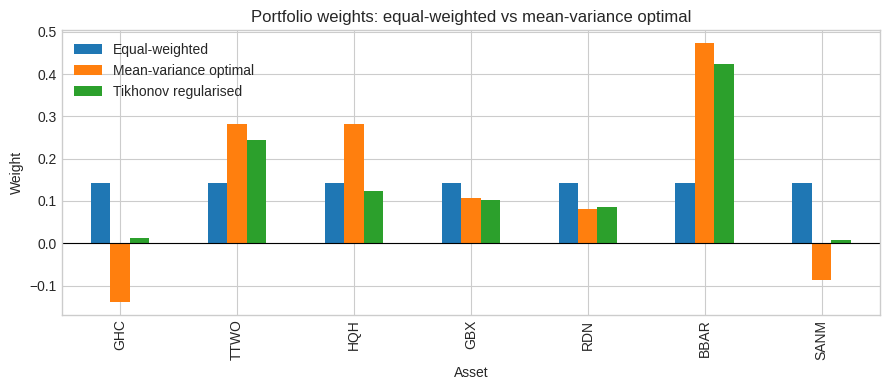

In [288]:
ax = weights_compare.plot(kind='bar', figsize=(9, 4), title='Portfolio weights: equal-weighted vs mean-variance optimal')
ax.set_xlabel('Asset')
ax.set_ylabel('Weight')
ax.axhline(0.0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## CAPM Evaluation of the Portfolios

After the portfolios are formed, we can still use the CAPM as a benchmark. We run the CAPM regression again, now on the **portfolio excess return**.

In [289]:
def portfolio_capm_summary(weights: pd.Series, returns: pd.DataFrame, rf: pd.Series, market_excess: pd.Series) -> pd.Series:
    portfolio_total = returns @ weights
    portfolio_excess = portfolio_total - rf

    X = sm.add_constant(market_excess)
    model = sm.OLS(portfolio_excess, X).fit()

    mean_excess = portfolio_excess.mean()
    sig = portfolio_excess.std(ddof=1)

    return pd.Series({
        'E[excess] (monthly)': mean_excess,
        'Vol (monthly)': sig,
        'Sharpe (monthly)': mean_excess / sig,
        'CAPM beta': model.params['Mkt-RF'],
        'CAPM required excess (monthly)': model.params['Mkt-RF'] * market_excess.mean(),
        'CAPM alpha (monthly)': model.params['const'],
        'CAPM alpha t-stat': model.tvalues['const'],
        'R-squared': model.rsquared,
    }, name=weights.name)


def market_capm_summary(market_excess: pd.Series) -> pd.Series:
    """CAPM benchmark row for the market portfolio.
    By construction: beta = 1, alpha = 0, R-squared = 1."""
    mean_excess = market_excess.mean()
    sig = market_excess.std(ddof=1)
    return pd.Series({
        'E[excess] (monthly)': mean_excess,
        'Vol (monthly)': sig,
        'Sharpe (monthly)': mean_excess / sig,
        'CAPM beta': 1.0,
        'CAPM required excess (monthly)': mean_excess,
        'CAPM alpha (monthly)': 0.0,
        'CAPM alpha t-stat': 0.0,
        'R-squared': 1.0,
    }, name='Market')


perf_full = pd.concat([
    portfolio_capm_summary(w_eq, stocks, rf, market_excess),
    portfolio_capm_summary(w_mkv, stocks, rf, market_excess),
    portfolio_capm_summary(w_tikh, stocks, rf, market_excess),
    market_capm_summary(market_excess),
], axis=1).T
perf_full

,E[excess] (monthly),Vol (monthly),Sharpe (monthly),CAPM beta,CAPM required excess (monthly),CAPM alpha (monthly),CAPM alpha t-stat,R-squared
Equal-weighted,0.016968,0.086812,0.195455,1.360346,0.009126,0.007842,2.341781,0.529224
Mean-variance optimal,0.026881,0.106583,0.252208,1.249816,0.008384,0.018497,3.679881,0.296357
Tikhonov regularised,0.025065,0.101247,0.247560,1.303065,0.008741,0.016323,3.576182,0.357001
Market,0.006708,0.046425,0.144499,1.000000,0.006708,0.000000,0.000000,1.000000


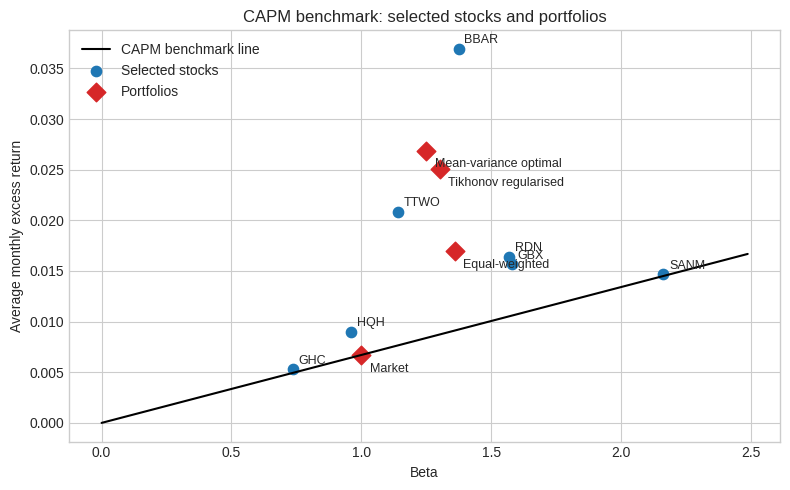

In [290]:
market_premium = market_excess.mean()
asset_points = alpha_table.loc[my_stock_selection, ['Beta', 'Mean excess return (monthly)']].copy()

fig, ax = plt.subplots(figsize=(8, 5))

beta_grid = np.linspace(0, max(asset_points['Beta'].max(), perf_full['CAPM beta'].max()) * 1.15, 100)
ax.plot(beta_grid, market_premium * beta_grid, color='black', linewidth=1.5, label='CAPM benchmark line')
ax.scatter(asset_points['Beta'], asset_points['Mean excess return (monthly)'], color='tab:blue', s=55, label='Selected stocks')
ax.scatter(perf_full['CAPM beta'], perf_full['E[excess] (monthly)'], color='tab:red', marker='D', s=90, label='Portfolios')

for ticker, row in asset_points.iterrows():
    ax.annotate(ticker, (row['Beta'], row['Mean excess return (monthly)']), xytext=(4, 4), textcoords='offset points', fontsize=9)
for portfolio_name, row in perf_full.iterrows():
    ax.annotate(portfolio_name, (row['CAPM beta'], row['E[excess] (monthly)']), xytext=(6, -12), textcoords='offset points', fontsize=9)

ax.set_title('CAPM benchmark: selected stocks and portfolios')
ax.set_xlabel('Beta')
ax.set_ylabel('Average monthly excess return')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Performance Analysis

In [291]:
# Change SPLIT_DATE to move the in-sample/out-of-sample boundary.
# Must fall within the dataset range: 1998-01-01 to 2024-12-01.
SPLIT_DATE = pd.Timestamp('2015-01-01')

train = df.loc[df.index < SPLIT_DATE].copy()
test  = df.loc[df.index >= SPLIT_DATE].copy()

print(f'Split date: {SPLIT_DATE.date()}')
print(f'In-sample observations:     {len(train)}')
print(f'Out-of-sample observations: {len(test)}')

Split date: 2015-01-01
In-sample observations:     204
Out-of-sample observations: 120


In [292]:
stocks_train = train[my_stock_selection].copy()
stocks_excess_train = stocks_train.subtract(train['RF'], axis=0)
mu_e_train = stocks_excess_train.mean()

R_train = stocks_train.subtract(stocks_train.mean())
T_train = len(stocks_train)
Sigma_train = (R_train.T @ R_train) / (T_train - 1)

w_mkv_train = tangency_weights(Sigma_train.values if hasattr(Sigma_train, 'values') else Sigma_train, mu_e_train.values)
w_mkv_train = pd.Series(w_mkv_train, index=my_stock_selection, name='Mean-variance optimal')

lambda_reg = 0.0147
Sigma_reg = Sigma_train + lambda_reg * np.eye(Sigma_train.shape[0])

w_tikh_train = tangency_weights(Sigma_reg, mu_e_train.values)
w_tikh_train = pd.Series(w_tikh_train, index=my_stock_selection, name='Tikhonov regularised')

w_eq_train = pd.Series(np.repeat(1 / len(my_stock_selection), len(my_stock_selection)), index=my_stock_selection, name='Equal-weighted')

pd.concat([w_eq_train, w_mkv_train, w_tikh_train], axis=1)

,Equal-weighted,Mean-variance optimal,Tikhonov regularised
GHC,0.142857,-0.128109,0.012559
TTWO,0.142857,0.191381,0.230645
HQH,0.142857,0.565814,0.258210
GBX,0.142857,0.175936,0.163594
RDN,0.142857,0.101988,0.109565
BBAR,0.142857,0.243203,0.260485
SANM,0.142857,-0.150213,-0.035059


# Determing Lambda Value

Optimal lambda: 0.0147


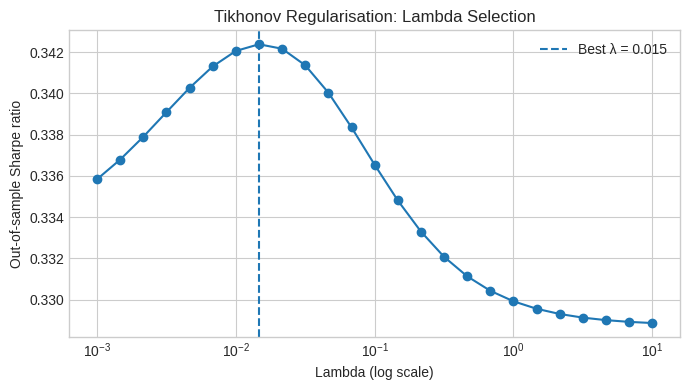

(    lambda   Sharpe    Alpha  Alpha t-stat      Vol
 7 0.014678 0.342375 0.021214      2.860848 0.096064
 8 0.021544 0.342158 0.020493      2.853551 0.094088
 6 0.010000 0.342051 0.021800      2.861214 0.097810
 9 0.031623 0.341355 0.019684      2.839172 0.092012
 5 0.006813 0.341300 0.022236      2.855709 0.099263,
 GHC    0.012040
 TTWO   0.243678
 HQH    0.123052
 GBX    0.102886
 RDN    0.085241
 BBAR   0.425025
 SANM   0.008079
 Name: Tikhonov regularised, dtype: float64)

In [293]:
#Lambda grid (log scale)
lambda_grid = np.logspace(-3, 1, 25)

results = []

for l in lambda_grid:
    #Regularise covariance matrix
    Sigma_reg = Sigma_np + l * np.eye(Sigma_np.shape[0])

    #Compute weights
    w = tangency_weights(Sigma_reg, mu_e.values)
    w = pd.Series(w, index=my_stock_selection)

    #Evaluate oos performance
    perf = portfolio_capm_summary(
        w,
        test[my_stock_selection],
        test['RF'],
        test['Mkt-RF']
    )

    results.append({
        'lambda': l,
        'Sharpe': perf['Sharpe (monthly)'],
        'Alpha': perf['CAPM alpha (monthly)'],
        'Alpha t-stat': perf['CAPM alpha t-stat'],
        'Vol': perf['Vol (monthly)']
    })

#Convert to DataFrame
lambda_results = pd.DataFrame(results)

#Select best lambda (max Sharpe)
best_idx = lambda_results['Sharpe'].idxmax()
best_lambda = lambda_results.loc[best_idx, 'lambda']

print(f"Optimal lambda: {best_lambda:.4f}")

#Recompute optimal weights using best lambda
Sigma_reg_best = Sigma_np + best_lambda * np.eye(Sigma_np.shape[0])
w_tikh = tangency_weights(Sigma_reg_best, mu_e.values)
w_tikh = pd.Series(w_tikh, index=my_stock_selection, name='Tikhonov regularised')

#Plot Sharpe vs Lambda
plt.figure(figsize=(7,4))
plt.plot(lambda_results['lambda'], lambda_results['Sharpe'], marker='o')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Out-of-sample Sharpe ratio')
plt.title('Tikhonov Regularisation: Lambda Selection')
plt.axvline(best_lambda, linestyle='--', label=f'Best λ = {best_lambda:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

#Output results
lambda_results.sort_values('Sharpe', ascending=False).head(), w_tikh

In [294]:
# ── In-sample portfolio returns ─────────────────────────────────────────────
portfolio_mkv_train  = train[my_stock_selection] @ w_mkv_train
portfolio_tikh_train = train[my_stock_selection] @ w_tikh_train
spy_train = train['SPY']

print('In-sample period:', train.index.min().date(), 'to', train.index.max().date())
print(f'Markowitz mean monthly return : {portfolio_mkv_train.mean():.6f}')
print(f'Tikhonov  mean monthly return : {portfolio_tikh_train.mean():.6f}')
print(f'S&P 500   mean monthly return : {spy_train.mean():.6f}')

In-sample period: 1998-01-01 to 2014-12-01
Markowitz mean monthly return : 0.021086
Tikhonov  mean monthly return : 0.020897
S&P 500   mean monthly return : 0.006510


### Mean Returns and Single-Factor CAPM Alpha (In-Sample)

We regress each portfolio's excess return on the market excess return:

$$r_{p,t} - r_{f,t} = \alpha + \beta (r_{m,t} - r_{f,t}) + \varepsilon_t$$

In [295]:
def capm_summary(port_ret, data, label):
    excess = port_ret - data['RF']
    X = sm.add_constant(data['Mkt-RF'])
    m = sm.OLS(excess, X).fit()
    return pd.Series({
        'Mean portfolio return (monthly)': port_ret.mean(),
        'Mean S&P 500 return (monthly)'  : data['SPY'].mean() if 'SPY' in data.columns else (data['Mkt-RF']+data['RF']).mean(),
        'CAPM Alpha (monthly)'           : m.params['const'],
        'CAPM Alpha (annualised)'        : (1+m.params['const'])**12 - 1,
        'Alpha t-stat'                   : m.tvalues['const'],
        'Market Beta'                    : m.params['Mkt-RF'],
        'R-squared'                      : m.rsquared,
    }, name=label)

capm_insample = pd.concat([
    capm_summary(portfolio_mkv_train,  train, 'Markowitz'),
    capm_summary(portfolio_tikh_train, train, 'Tikhonov'),
], axis=1).T
capm_insample

,Mean portfolio return (monthly),Mean S&P 500 return (monthly),CAPM Alpha (monthly),CAPM Alpha (annualised),Alpha t-stat,Market Beta,R-squared
Markowitz,0.021086,0.006510,0.013930,0.180575,2.823611,1.098496,0.350511
Tikhonov,0.020897,0.006510,0.012878,0.165959,2.632496,1.275615,0.425330


### Fama-French Factor Regressions (In-Sample)

In [296]:
def run_ff_regression(portfolio_returns, data, factors):
    Y = portfolio_returns - data['RF']
    X = sm.add_constant(data[factors])
    return sm.OLS(Y, X).fit()

def ff_table(models_dict):
    rows = []
    for model_name, m in models_dict.items():
        for param in m.params.index:
            rows.append({'Model': model_name, 'Factor': param,
                         'Coefficient': m.params[param], 't-stat': m.tvalues[param]})
    return pd.DataFrame(rows).set_index(['Model','Factor'])

capm_f = ['Mkt-RF']
ff3_f  = ['Mkt-RF', 'SMB', 'HML']
ff5_f  = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

# ── Markowitz In-Sample ──────────────────────────────────────────────────────
print('=== MARKOWITZ – In-Sample Factor Regressions ===')
mkv_models_train = {
    'CAPM' : run_ff_regression(portfolio_mkv_train,  train, capm_f),
    'FF3'  : run_ff_regression(portfolio_mkv_train,  train, ff3_f),
    'FF5'  : run_ff_regression(portfolio_mkv_train,  train, ff5_f),
}
for name, m in mkv_models_train.items():
    print(f'\n{name}  (R²={m.rsquared:.4f})')
    print(pd.concat([m.params.rename('Coef'), m.tvalues.rename('t-stat')], axis=1).round(4))

# ── Tikhonov In-Sample ───────────────────────────────────────────────────────
print('\n=== TIKHONOV – In-Sample Factor Regressions ===')
tikh_models_train = {
    'CAPM' : run_ff_regression(portfolio_tikh_train, train, capm_f),
    'FF3'  : run_ff_regression(portfolio_tikh_train, train, ff3_f),
    'FF5'  : run_ff_regression(portfolio_tikh_train, train, ff5_f),
}
for name, m in tikh_models_train.items():
    print(f'\n{name}  (R²={m.rsquared:.4f})')
    print(pd.concat([m.params.rename('Coef'), m.tvalues.rename('t-stat')], axis=1).round(4))

=== MARKOWITZ – In-Sample Factor Regressions ===

CAPM  (R²=0.3505)
           Coef    t-stat
const  0.013900  2.823600
Mkt-RF 1.098500 10.441000

FF3  (R²=0.4799)
            Coef    t-stat
const   0.012400  2.784600
Mkt-RF  0.921200  9.394400
SMB     0.936200  6.707500
HML    -0.229700 -1.658500

FF5  (R²=0.4881)
            Coef    t-stat
const   0.013700  2.947400
Mkt-RF  0.848700  7.120900
SMB     0.799200  5.019300
HML    -0.140500 -0.681600
RMW    -0.346900 -1.660900
CMA     0.120400  0.428400

=== TIKHONOV – In-Sample Factor Regressions ===

CAPM  (R²=0.4253)
           Coef    t-stat
const  0.012900  2.632500
Mkt-RF 1.275600 12.227300

FF3  (R²=0.4930)
           Coef    t-stat
const  0.011000  2.366600
Mkt-RF 1.159700 11.362000
SMB    0.749600  5.159200
HML    0.090900  0.630500

FF5  (R²=0.4965)
            Coef    t-stat
const   0.011700  2.396100
Mkt-RF  1.120300  8.991000
SMB     0.656300  3.942700
HML     0.124400  0.577300
RMW    -0.224600 -1.028800
CMA     0.135800  0.

In [297]:
def compact_ff5(m, label):
    cols = ['const'] + ff5_f
    coef = m.params.reindex(cols).rename(lambda x: x if x != 'const' else 'Alpha')
    tval = m.tvalues.reindex(cols).rename(lambda x: x if x != 'const' else 'Alpha')
    idx  = pd.MultiIndex.from_tuples([(label, c) for c in coef.index])
    return pd.DataFrame({'Coefficient': coef.values, 't-stat': tval.values}, index=idx)

ff5_insample_summary = pd.concat([
    compact_ff5(mkv_models_train['FF5'],  'Markowitz'),
    compact_ff5(tikh_models_train['FF5'], 'Tikhonov'),
])
print('=== FF5 In-Sample Summary ===')
ff5_insample_summary.round(4)

=== FF5 In-Sample Summary ===


Coefficient    t-stat
Markowitz Alpha      0.013700  2.947400
          Mkt-RF     0.848700  7.120900
          SMB        0.799200  5.019300
          HML       -0.140500 -0.681600
          RMW       -0.346900 -1.660900
          CMA        0.120400  0.428400
Tikhonov  Alpha      0.011700  2.396100
          Mkt-RF     1.120300  8.991000
          SMB        0.656300  3.942700
          HML        0.124400  0.577300
          RMW       -0.224600 -1.028800
          CMA        0.135800  0.462300

### In-Sample Performance Comparison: Markowitz vs Tikhonov

In [298]:
def perf_summary(port_ret, data, label):
    excess = port_ret - data['RF']
    m_capm = run_ff_regression(port_ret, data, capm_f)
    return pd.Series({
        'Mean return (monthly)':   port_ret.mean(),
        'Std dev (monthly)':       port_ret.std(ddof=1),
        'Sharpe (annualised)':     excess.mean() / excess.std(ddof=1) * (12**0.5),
        'CAPM Alpha (monthly)':    m_capm.params['const'],
        'CAPM Alpha t-stat':       m_capm.tvalues['const'],
        'Market Beta':             m_capm.params['Mkt-RF'],
        'Max drawdown':            (port_ret.add(1).cumprod() / port_ret.add(1).cumprod().cummax() - 1).min(),
    }, name=label)

in_sample_comparison = pd.concat([
    perf_summary(portfolio_mkv_train,  train, 'Markowitz'),
    perf_summary(portfolio_tikh_train, train, 'Tikhonov'),
    perf_summary(spy_train,            train, 'S&P 500'),
], axis=1).T
in_sample_comparison.round(4)

,Mean return (monthly),Std dev (monthly),Sharpe (annualised),CAPM Alpha (monthly),CAPM Alpha t-stat,Market Beta,Max drawdown
Markowitz,0.021100,0.086500,0.770100,0.013900,2.823600,1.098500,-0.503400
Tikhonov,0.020900,0.091200,0.723400,0.012900,2.632500,1.275600,-0.637500
S&P 500,0.006500,0.046600,0.349000,0.000300,0.200200,0.909800,-0.484800


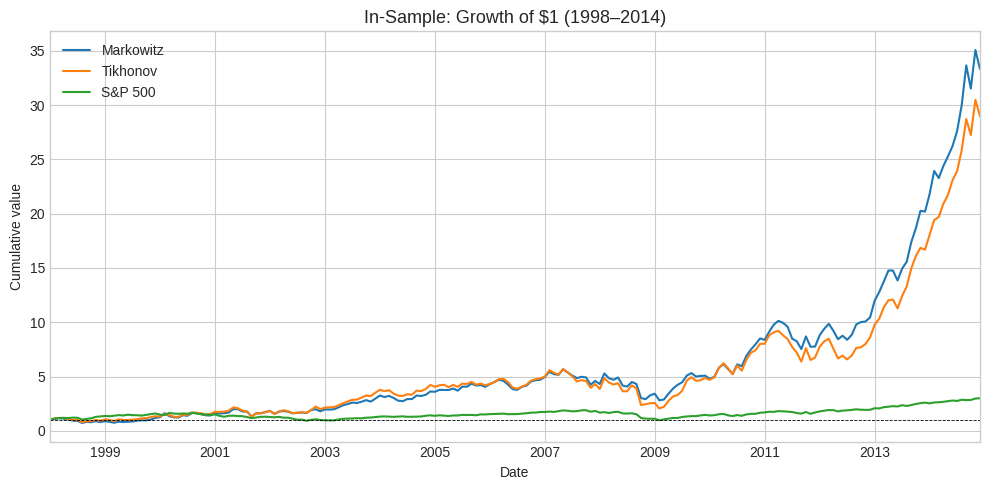

In [299]:
wealth_train = pd.DataFrame({
    'Markowitz':  (1 + portfolio_mkv_train).cumprod(),
    'Tikhonov':   (1 + portfolio_tikh_train).cumprod(),
    'S&P 500':    (1 + spy_train).cumprod(),
}, index=train.index)

ax = wealth_train.plot(figsize=(10, 5))
ax.set_title('In-Sample: Growth of $1 (1998–2014)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative value')
ax.axhline(1.0, color='black', linewidth=0.6, linestyle='--')
plt.tight_layout()
plt.show()

## 7. Out-of-Sample Performance Analysis

The **same weights** determined from the in-sample optimisation (`w_mkv_train` and `w_tikh_train`) are applied unchanged to the **out-of-sample period (January 2015 – December 2024)**.

In [300]:
# ── Apply in-sample weights to out-of-sample data ──────────────────────────
portfolio_mkv_test  = test[my_stock_selection] @ w_mkv_train
portfolio_tikh_test = test[my_stock_selection] @ w_tikh_train
spy_test = test['SPY']

print('Out-of-sample period:', test.index.min().date(), 'to', test.index.max().date())
print(f'Markowitz mean monthly return : {portfolio_mkv_test.mean():.6f}')
print(f'Tikhonov  mean monthly return : {portfolio_tikh_test.mean():.6f}')
print(f'S&P 500   mean monthly return : {spy_test.mean():.6f}')

Out-of-sample period: 2015-01-01 to 2024-12-01
Markowitz mean monthly return : 0.021537
Tikhonov  mean monthly return : 0.024702
S&P 500   mean monthly return : 0.011330


### Mean Returns and Single-Factor CAPM Alpha (Out-of-Sample)

In [301]:
capm_outsample = pd.concat([
    capm_summary(portfolio_mkv_test,  test, 'Markowitz'),
    capm_summary(portfolio_tikh_test, test, 'Tikhonov'),
], axis=1).T
capm_outsample

,Mean portfolio return (monthly),Mean S&P 500 return (monthly),CAPM Alpha (monthly),CAPM Alpha (annualised),Alpha t-stat,Market Beta,R-squared
Markowitz,0.021537,0.011330,0.008838,0.111362,1.585628,1.150520,0.441046
Tikhonov,0.024702,0.011330,0.011911,0.152679,2.270711,1.159858,0.475163


###Fama-French Factor Regressions (Out-of-Sample)

In [302]:
# ── Markowitz Out-of-Sample ─────────────────────────────────────────────────
print('=== MARKOWITZ – Out-of-Sample Factor Regressions ===')
mkv_models_test = {
    'CAPM' : run_ff_regression(portfolio_mkv_test,  test, capm_f),
    'FF3'  : run_ff_regression(portfolio_mkv_test,  test, ff3_f),
    'FF5'  : run_ff_regression(portfolio_mkv_test,  test, ff5_f),
}
for name, m in mkv_models_test.items():
    print(f'\n{name}  (R²={m.rsquared:.4f})')
    print(pd.concat([m.params.rename('Coef'), m.tvalues.rename('t-stat')], axis=1).round(4))

# ── Tikhonov Out-of-Sample ───────────────────────────────────────────────────
print('\n=== TIKHONOV – Out-of-Sample Factor Regressions ===')
tikh_models_test = {
    'CAPM' : run_ff_regression(portfolio_tikh_test, test, capm_f),
    'FF3'  : run_ff_regression(portfolio_tikh_test, test, ff3_f),
    'FF5'  : run_ff_regression(portfolio_tikh_test, test, ff5_f),
}
for name, m in tikh_models_test.items():
    print(f'\n{name}  (R²={m.rsquared:.4f})')
    print(pd.concat([m.params.rename('Coef'), m.tvalues.rename('t-stat')], axis=1).round(4))

=== MARKOWITZ – Out-of-Sample Factor Regressions ===

CAPM  (R²=0.4410)
           Coef   t-stat
const  0.008800 1.585600
Mkt-RF 1.150500 9.649300

FF3  (R²=0.4482)
            Coef    t-stat
const   0.009700  1.714500
Mkt-RF  1.100300  8.708700
SMB     0.250800  1.217100
HML    -0.050700 -0.326600

FF5  (R²=0.4510)
            Coef    t-stat
const   0.010300  1.798300
Mkt-RF  1.103700  8.259700
SMB     0.160300  0.670300
HML     0.037900  0.173500
RMW    -0.202000 -0.666000
CMA    -0.123200 -0.375200

=== TIKHONOV – Out-of-Sample Factor Regressions ===

CAPM  (R²=0.4752)
           Coef    t-stat
const  0.011900  2.270700
Mkt-RF 1.159900 10.335900

FF3  (R²=0.4853)
           Coef   t-stat
const  0.012800 2.422700
Mkt-RF 1.121200 9.460000
SMB    0.172100 0.890500
HML    0.119300 0.819600

FF5  (R²=0.4881)
            Coef    t-stat
const   0.013300  2.468300
Mkt-RF  1.109000  8.849600
SMB     0.103700  0.462100
HML     0.231400  1.127900
RMW    -0.114900 -0.404100
CMA    -0.209200 -0.

In [303]:
ff5_outsample_summary = pd.concat([
    compact_ff5(mkv_models_test['FF5'],  'Markowitz'),
    compact_ff5(tikh_models_test['FF5'], 'Tikhonov'),
])
print('=== FF5 Out-of-Sample Summary ===')
ff5_outsample_summary.round(4)

=== FF5 Out-of-Sample Summary ===


Coefficient    t-stat
Markowitz Alpha      0.010300  1.798300
          Mkt-RF     1.103700  8.259700
          SMB        0.160300  0.670300
          HML        0.037900  0.173500
          RMW       -0.202000 -0.666000
          CMA       -0.123200 -0.375200
Tikhonov  Alpha      0.013300  2.468300
          Mkt-RF     1.109000  8.849600
          SMB        0.103700  0.462100
          HML        0.231400  1.127900
          RMW       -0.114900 -0.404100
          CMA       -0.209200 -0.679700

###Out-of-Sample Performance Comparison: Markowitz vs Tikhonov

In [304]:
out_sample_comparison = pd.concat([
    perf_summary(portfolio_mkv_test,  test, 'Markowitz'),
    perf_summary(portfolio_tikh_test, test, 'Tikhonov'),
    perf_summary(spy_test,            test, 'S&P 500'),
], axis=1).T
out_sample_comparison.round(4)

,Mean return (monthly),Std dev (monthly),Sharpe (annualised),CAPM Alpha (monthly),CAPM Alpha t-stat,Market Beta,Max drawdown
Markowitz,0.021500,0.079700,0.877600,0.008800,1.585600,1.150500,-0.330400
Tikhonov,0.024700,0.077500,1.045600,0.011900,2.270700,1.159900,-0.338500
S&P 500,0.011300,0.046400,0.741500,0.000400,0.337600,0.967800,-0.229200


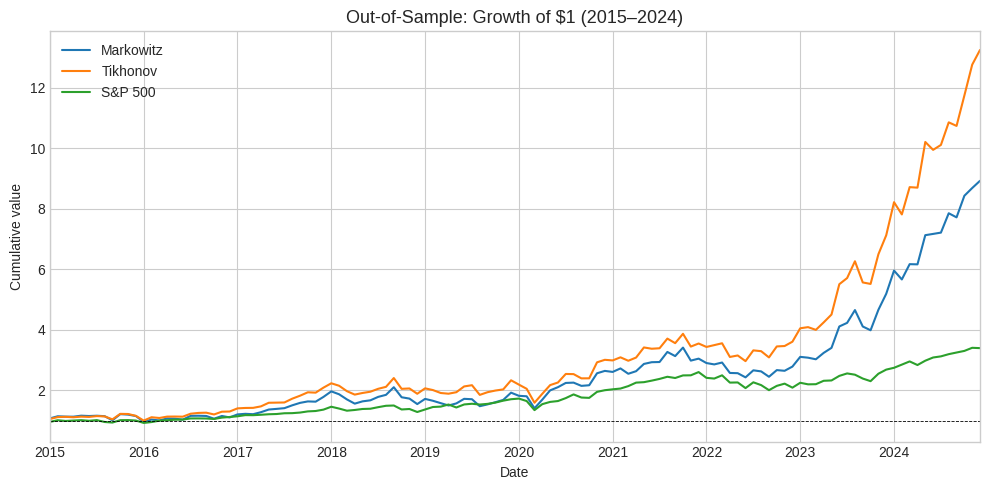

In [305]:
wealth_test = pd.DataFrame({
    'Markowitz': (1 + portfolio_mkv_test).cumprod(),
    'Tikhonov':  (1 + portfolio_tikh_test).cumprod(),
    'S&P 500':   (1 + spy_test).cumprod(),
}, index=test.index)

ax = wealth_test.plot(figsize=(10, 5))
ax.set_title('Out-of-Sample: Growth of $1 (2015–2024)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative value')
ax.axhline(1.0, color='black', linewidth=0.6, linestyle='--')
plt.tight_layout()
plt.show()

### Full Performance Summary: In-Sample vs Out-of-Sample

In [306]:
full_comparison = pd.concat([
    in_sample_comparison.assign(Period='In-sample'),
    out_sample_comparison.assign(Period='Out-of-sample'),
]).reset_index().rename(columns={'index': 'Portfolio'}).set_index(['Period', 'Portfolio'])
full_comparison.round(4)

Mean return (monthly)  Std dev (monthly)  \
Period        Portfolio                                             
In-sample     Markowitz               0.021100           0.086500   
              Tikhonov                0.020900           0.091200   
              S&P 500                 0.006500           0.046600   
Out-of-sample Markowitz               0.021500           0.079700   
              Tikhonov                0.024700           0.077500   
              S&P 500                 0.011300           0.046400   

                         Sharpe (annualised)  CAPM Alpha (monthly)  \
Period        Portfolio                                              
In-sample     Markowitz             0.770100              0.013900   
              Tikhonov              0.723400              0.012900   
              S&P 500               0.349000              0.000300   
Out-of-sample Markowitz             0.877600              0.008800   
              Tikhonov              1.045600              0.011900   
              S&P 500               0.741500              0.000400   

                         CAPM Alpha t-stat  Market Beta  Max drawdown  
Period        Portfolio                                                
In-sample     Markowitz           2.823600     1.098500     -0.503400  
              Tikhonov            2.632500     1.275600     -0.637500  
              S&P 500             0.200200     0.909800     -0.484800  
Out-of-sample Markowitz           1.585600     1.150500     -0.330400  
              Tikhonov            2.270700     1.159900     -0.338500  
              S&P 500             0.337600     0.967800     -0.229200